In [1]:
# ! pip install kagglehub
# !pip install split-folders

In [2]:
# other datasets to test
# https://www.kaggle.com/datasets/harisudhan411/hand-navigation-landmarks

In [41]:
import os
from collections import defaultdict
import matplotlib.pyplot as plt
import pandas as pd
import random as random
import shutil as shutil

In [4]:
import kagglehub

# Download latest version
# path = kagglehub.dataset_download("gti-upm/leapgestrecog")

# print("Path to dataset files:", path)

In [5]:
# UP : palm
# DOWN : fist 
# LEFT : thumb 
# RIGHT : index

In [6]:
data_path = "./data/raw/leapGestRecog/"

total_images = 0

for subject in os.listdir(data_path): 
    subject_path = os.path.join(data_path, subject)
    
    for gesture in os.listdir(subject_path): 
        
        gesture_path = os.path.join(subject_path, gesture)
        
        total_images += len(os.listdir(gesture_path))
        
print(f"Total Images: {total_images}")

Total Images: 20000


In [7]:
images_per_gesture = defaultdict(int)

gestures = [] 
values = []

for subject in os.listdir(data_path): 
    subject_path = os.path.join(data_path, subject)
    
    for gesture in os.listdir(subject_path): 
        
        gesture_path = os.path.join(subject_path, gesture)
        
        images_per_gesture[gesture[3:]]+= len(os.listdir(gesture_path))
        
for key, value in images_per_gesture.items(): 
    gestures.append(key) 
    values.append(value)
    print(f"Gesture: {key}, Number of Images: {value}")

Gesture: palm, Number of Images: 2000
Gesture: l, Number of Images: 2000
Gesture: fist, Number of Images: 2000
Gesture: fist_moved, Number of Images: 2000
Gesture: thumb, Number of Images: 2000
Gesture: index, Number of Images: 2000
Gesture: ok, Number of Images: 2000
Gesture: palm_moved, Number of Images: 2000
Gesture: c, Number of Images: 2000
Gesture: down, Number of Images: 2000


<Axes: >

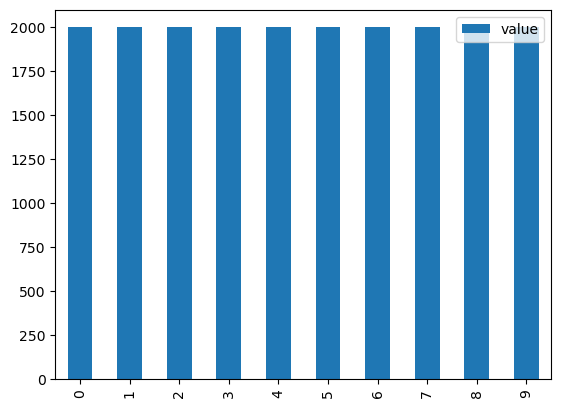

In [8]:
pd.DataFrame({
    'gesture': gestures,
    'value': values
}).plot(kind='bar')

In [48]:

train_dir = "./data/train"
val_dir = "./data/validation"
GESTURES = ["palm", "fist", "thumb", "index"]

for subject in os.listdir(data_path): 
    subject_path = os.path.join(data_path, subject)

    subject_gestures = defaultdict(list)
    
    for gesture in os.listdir(subject_path): 
        
        if gesture[3:] not in GESTURES: 
            continue


        gesture_images = []
        gesture_path = os.path.join(subject_path, gesture)

        images = [(os.path.join(gesture_path, img)) for img in os.listdir(gesture_path)]
        # for img in os.listdir(gesture_path): 
        #     print(os.path.join(gesture_path, img))
        
        subject_gestures[gesture[3:]].extend(images)

    for gesture_name, images in subject_gestures.items():
        random.shuffle(images)
        split = int(len(images) * 0.8) # index of where to split
        train_images = images[:split]
        val_images = images[split:]

        for img in train_images:
            shutil.copy(img, os.path.join(train_dir, gesture_name, os.path.basename(img)))
        for img in val_images:
            shutil.copy(img, os.path.join(val_dir, gesture_name, os.path.basename(img)))

    # print(subject_gestures)
